# EDA

In [1]:
"""
Purpose of this script:
To explore the salient features of the given dataset (diabetes-130),
What are the categorical, numerical variables?
How many rows, many columns?
Any outliers? Where they exist?
How much % missing?
Distribution, which columns is skewed?
Find some patterns between the data and what we are potentially interested in.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import statsmodels.api as sm
import scipy

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
data_path = "../data/"
output_path = "../output/"

### Fetch data from pre-saved parquet file

In [3]:
data = pd.read_parquet(data_path + "diabetes_130_full.parquet")
X = pd.read_parquet(data_path + "diabetes_130_X.parquet")
y = pd.read_parquet(data_path + "diabetes_130_y.parquet")

In [4]:
data.drop(columns = ['encounter_id', 'patient_nbr'], inplace = True)

### Fetch data directly from API (First Call)

In [5]:
# from ucimlrepo import fetch_ucirepo, list_available_datasets
# import pprint

# diabetes_dataset = fetch_ucirepo(id=296)

In [6]:
# getting info directly from the pre-describe metadata first

diabetes_dataset = pd.read_csv(output_path + "dataset_description.csv")

In [7]:
# diabetes_dataset.metadata.missing_values_symbol 

# This means only value of NaN represent the true missing value. 

### Summary Statistics (Basic Overview)

In [8]:
"""
Purpose is to explore the following:
Dataset shape - rows, columns
Data types - numeric, categorical
Missing values - count, percentage
Duplicate rows - exact and near-duplicates
Unique values per column
Cardinality of categorical variables
"""
pass

In [9]:
data.shape 
# 101,766 rows, 48 cols

(101766, 48)

In [10]:
# Descriptive statistics

data.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [11]:
# Features vs Target

features = X.columns.tolist()
target = y.columns.tolist()

print(f"X = {features}\n")
print(f"y = {target}\n")

print(f"num_X = {len(features)}") # 47 features
print(f"num_y = {len(target)}")   # 1 target

X = ['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

y = ['readmitted']

num_X = 47
num_y = 1


In [12]:
# Type of variables

pre_described_data = diabetes_dataset

categorical_var = pre_described_data[pre_described_data['type'] == 'Categorical']['name'].tolist()
numerical_var = pre_described_data[pre_described_data['type'] == 'Integer']['name'].tolist()
medication_var = [col for col in pre_described_data['name'] if any(med in col.lower() for med in 
                  ['metformin', 'glipizide', 'glyburide', 'insulin', 'pioglitazone', 
                   'rosiglitazone', 'repaglinide', 'nateglinide', 'chlorpropamide',
                   'glimepiride', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol',
                   'troglitazone', 'tolazamide', 'examide', 'citoglipton'])]

print(f"num_of_categorical_var: {len(categorical_var)}")
print(f"num_of_numerical_var: {len(numerical_var)}")
print(f"num_of_medication_var: {len(medication_var)}")

num_of_categorical_var: 40
num_of_numerical_var: 8
num_of_medication_var: 23


In [13]:
# Missing Analysis (% Missing)

var_with_missing = pre_described_data[pre_described_data['missing_values'] == 'yes']['name'].tolist()
missing_results = data[var_with_missing].isnull().sum() / len(data)

print("\nVariables with any missing values (descending)")
missing_results.sort_values(ascending = False)


Variables with any missing values (descending)


weight               0.968585
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
dtype: float64

In [14]:
# decide to drop weight first, very high missing rate (97%). Drop payer_code also, dont think there's relevance at all.
# keep medical_speciality first, might be valuable knowing who admitted them.

data_clean = data.drop(columns = ['weight', 'payer_code'], axis = 1)

In [15]:
df = data_clean.copy()

### Target Variable Analysis (Re-admission Status)



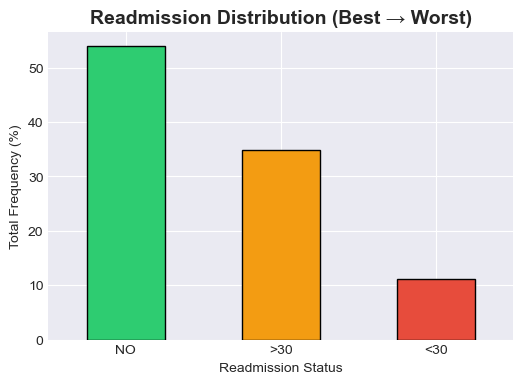

In [16]:
"""
I think we can interpret the readmitted status as Ordinal, rather than Nominal.
NO → >30 → <30 (with increasing level of medical concern)
"""

ordinal_mapping = {'NO': 0, '>30': 1, '<30': 2}
df['readmitted_ordinal'] = df['readmitted'].map(ordinal_mapping)

readmit_order = ['NO', '>30', '<30']
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green → Orange → Red

target_pct = df['readmitted'].value_counts(normalize = True).reindex(readmit_order) * 100

plt.figure(figsize=(6,4))
target_pct.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Readmission Distribution (Best → Worst)', fontsize=14, fontweight='bold')
plt.xlabel('Readmission Status')
plt.ylabel('Total Frequency (%)')
plt.xticks(rotation=0)
plt.show()

### Numerical Variable Analysis

#### Histogram Distribution

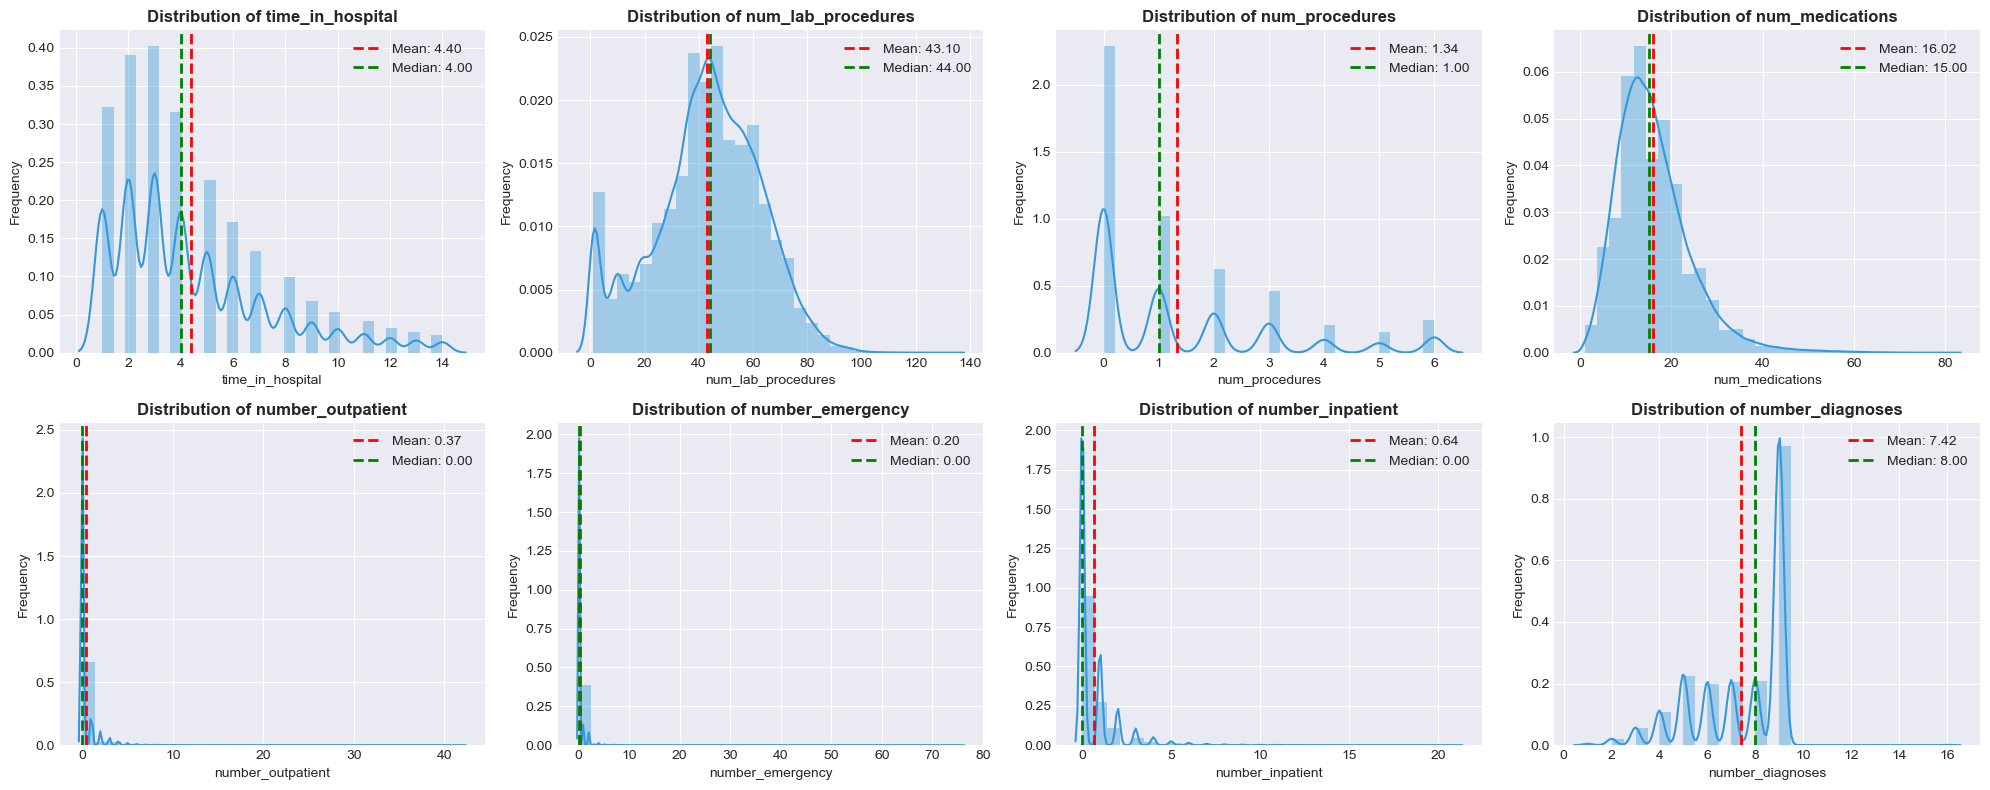

In [17]:
# Layout setup - 4 graphs side by side per row.
n_cols = 4
n_rows = (len(numerical_var) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_var):
    sns.distplot(df[col], bins=30, kde=True, color="#3498db", ax=axes[i])

    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
    axes[i].axvline(median_val, color="green", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

    axes[i].set_title(f"Distribution of {col}", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Skewness Analysis (Kurtosis)

               Column   Skewness     Kurtosis         Skew_Type
0    number_emergency  22.855582  1191.686726      Right Skewed
1   number_outpatient   8.832959   147.907736      Right Skewed
2    number_inpatient   3.614139    20.719397      Right Skewed
3     num_medications   1.326672     3.468155      Right Skewed
4      num_procedures   1.316415     0.857110      Right Skewed
5    time_in_hospital   1.133999     0.850251      Right Skewed
6  num_lab_procedures  -0.236544    -0.245074  Fairly Symmetric
7    number_diagnoses  -0.876746    -0.079056       Left Skewed 



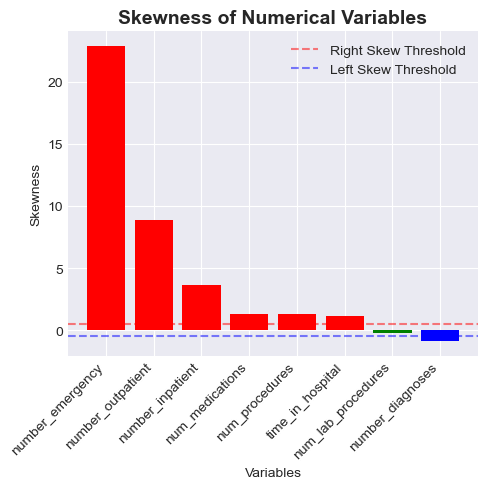

In [18]:
# Calculate skewness for numerical features
skewness_data = []
for col in numerical_var:
    col_skew = df[col].skew()
    col_kurt = df[col].kurtosis()
    skewness_data.append({
        'Column': col,
        'Skewness': col_skew,
        'Kurtosis': col_kurt,
        'Skew_Type': 'Right Skewed' if col_skew > 0.5 else 'Left Skewed' if col_skew < -0.5 else 'Fairly Symmetric'
    })

skewness_df = pd.DataFrame(skewness_data).sort_values('Skewness', ascending=False).reset_index(drop = True)

print(skewness_df, "\n")

# Visualize skewness
plt.figure(figsize=(5, 5))
colors = ['red' if x > 0.5 else 'blue' if x < -0.5 else 'green' for x in skewness_df['Skewness']]
plt.bar(range(len(skewness_df)), skewness_df['Skewness'], color=colors)
plt.xticks(range(len(skewness_df)), skewness_df['Column'], rotation=45, ha='right')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Right Skew Threshold')
plt.axhline(y=-0.5, color='b', linestyle='--', alpha=0.5, label='Left Skew Threshold')
plt.xlabel('Variables')
plt.ylabel('Skewness')
plt.title('Skewness of Numerical Variables', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

#### Outlier analysis


📊 Outlier Summary (IQR Method):
               Column  Outlier_Count  Outlier_Percentage  Lower_Bound  \
4   number_outpatient          16739           16.448519          0.0   
5    number_emergency          11383           11.185465          0.0   
6    number_inpatient           7049            6.926675         -1.5   
2      num_procedures           4954            4.868031         -3.0   
3     num_medications           2557            2.512627         -5.0   
0    time_in_hospital           2252            2.212920         -4.0   
7    number_diagnoses            281            0.276124          1.5   
1  num_lab_procedures            143            0.140518         -8.0   

   Upper_Bound  Min  Max  
4          0.0    0   42  
5          0.0    0   76  
6          2.5    0   21  
2          5.0    0    6  
3         35.0    1   81  
0         12.0    1   14  
7         13.5    1   16  
1         96.0    1  132  


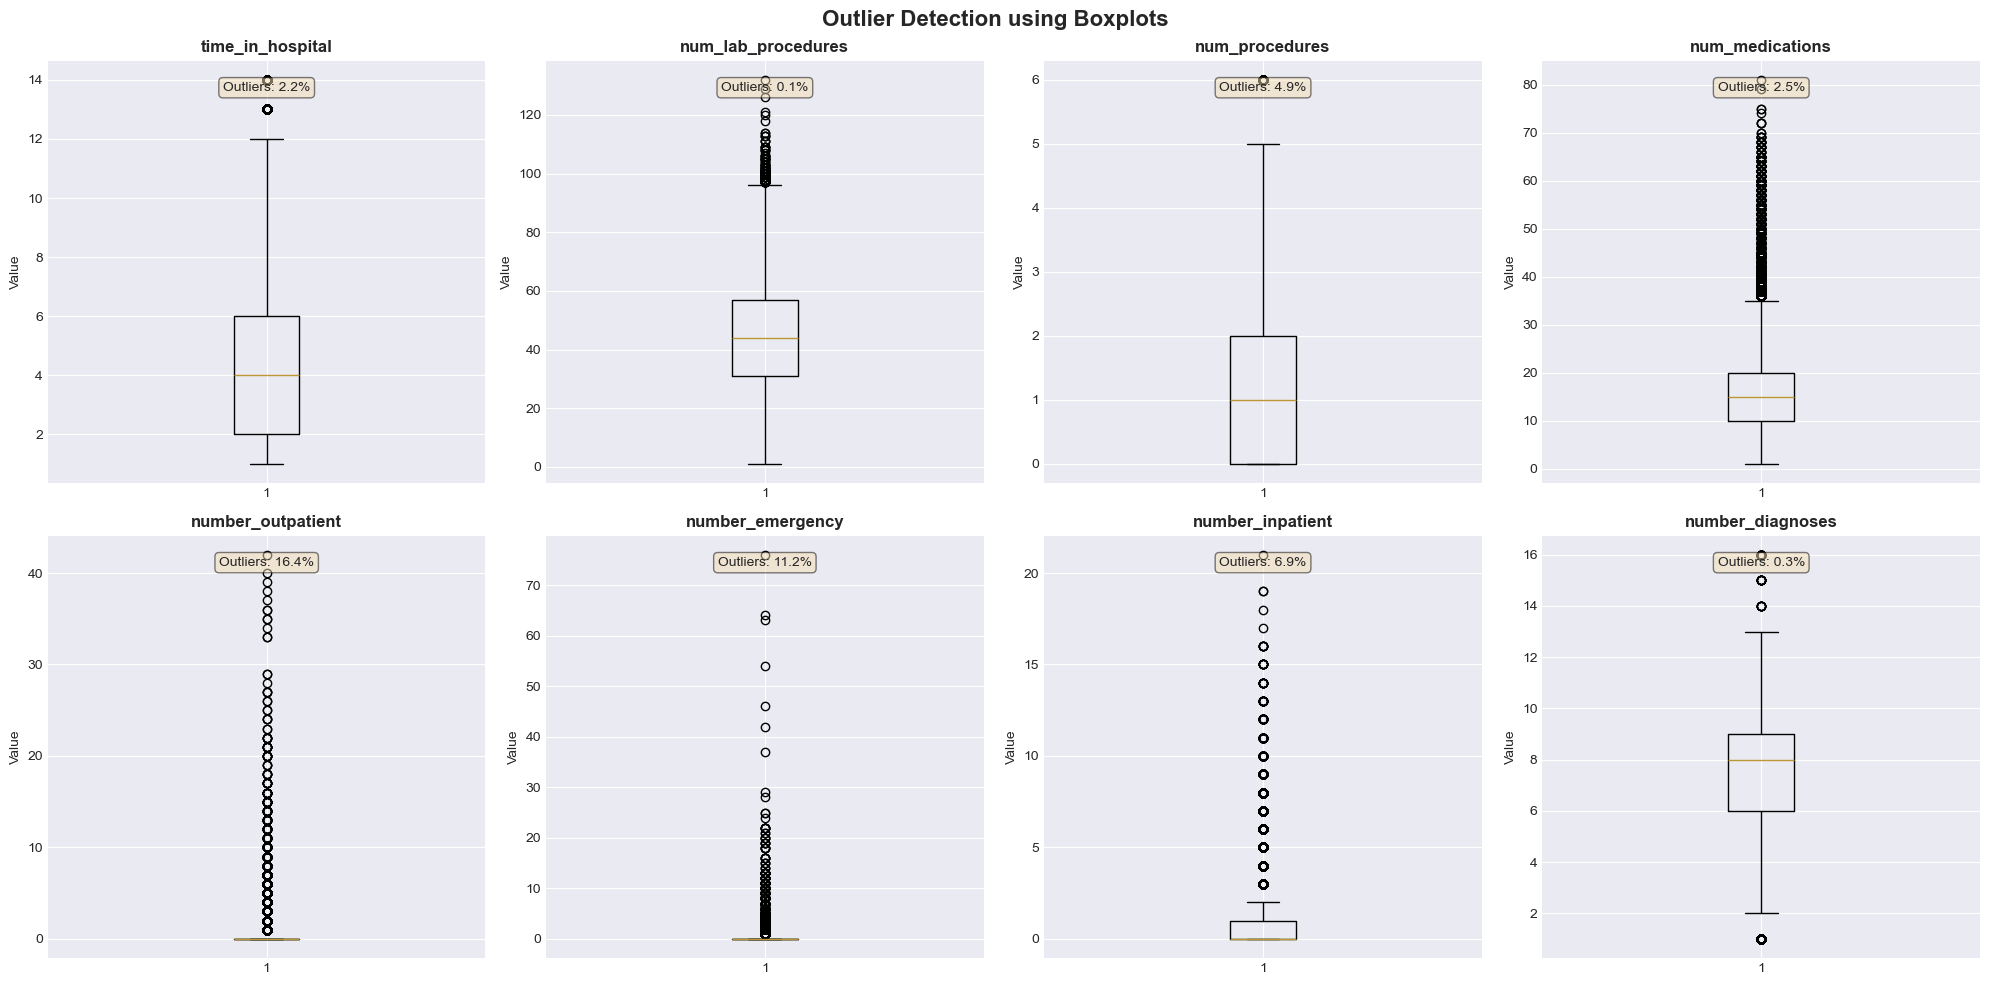

In [23]:
# Calculate outliers using IQR method
outlier_summary = []
for col in numerical_var:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_percentage,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Min': df[col].min(),
        'Max': df[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
print("\n📊 Outlier Summary (IQR Method):")
print(outlier_df)

fig, axes = plt.subplots(2, (len(numerical_var) + 1) // 2, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_var):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Value')
    
    # Add outlier percentage
    outlier_pct = outlier_df[outlier_df['Column'] == col]['Outlier_Percentage'].values[0]
    axes[i].text(0.5, 0.95, f'Outliers: {outlier_pct:.1f}%', 
                transform=axes[i].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Detection using Boxplots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Relationship between numerical vs target-ordinal variable

#### Correlation amongst numerical features

In [19]:
numerical_with_target = numerical_var.copy()
numerical_with_target.append('readmitted_ordinal')

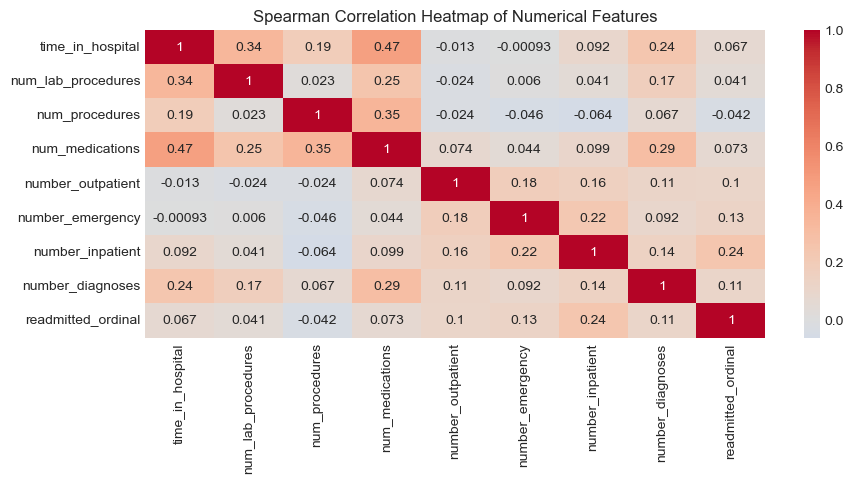

In [20]:
corr_matrix = df[numerical_with_target].corr(method='spearman')

plt.figure(figsize=(10,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap of Numerical Features")
plt.show()

#### Somers'D - measure the concordance between 2 ordering variables

In [22]:
results = []
for col in numerical_var:
    somers_d = scipy.stats.somersd(df[col], df['readmitted_ordinal'])
    results.append({
        "Variable": col,
        "SomersD": somers_d.statistic,
        "p_value": somers_d.pvalue
    })

somers_df = pd.DataFrame(results).sort_values("SomersD", ascending=False)
print(somers_df)

# seems like the top 3 variable here have some linear relationship with the ordinal variables

             Variable   SomersD        p_value
6    number_inpatient  0.229152   0.000000e+00
5    number_emergency  0.200836   0.000000e+00
4   number_outpatient  0.136981  1.233267e-238
7    number_diagnoses  0.083316  1.164964e-261
3     num_medications  0.045637  1.126444e-122
0    time_in_hospital  0.044786  1.325255e-101
1  num_lab_procedures  0.024752   3.440149e-39
2      num_procedures -0.032415   2.025160e-40


#### Box-plots to compare numerical variables vs multiclass target variable

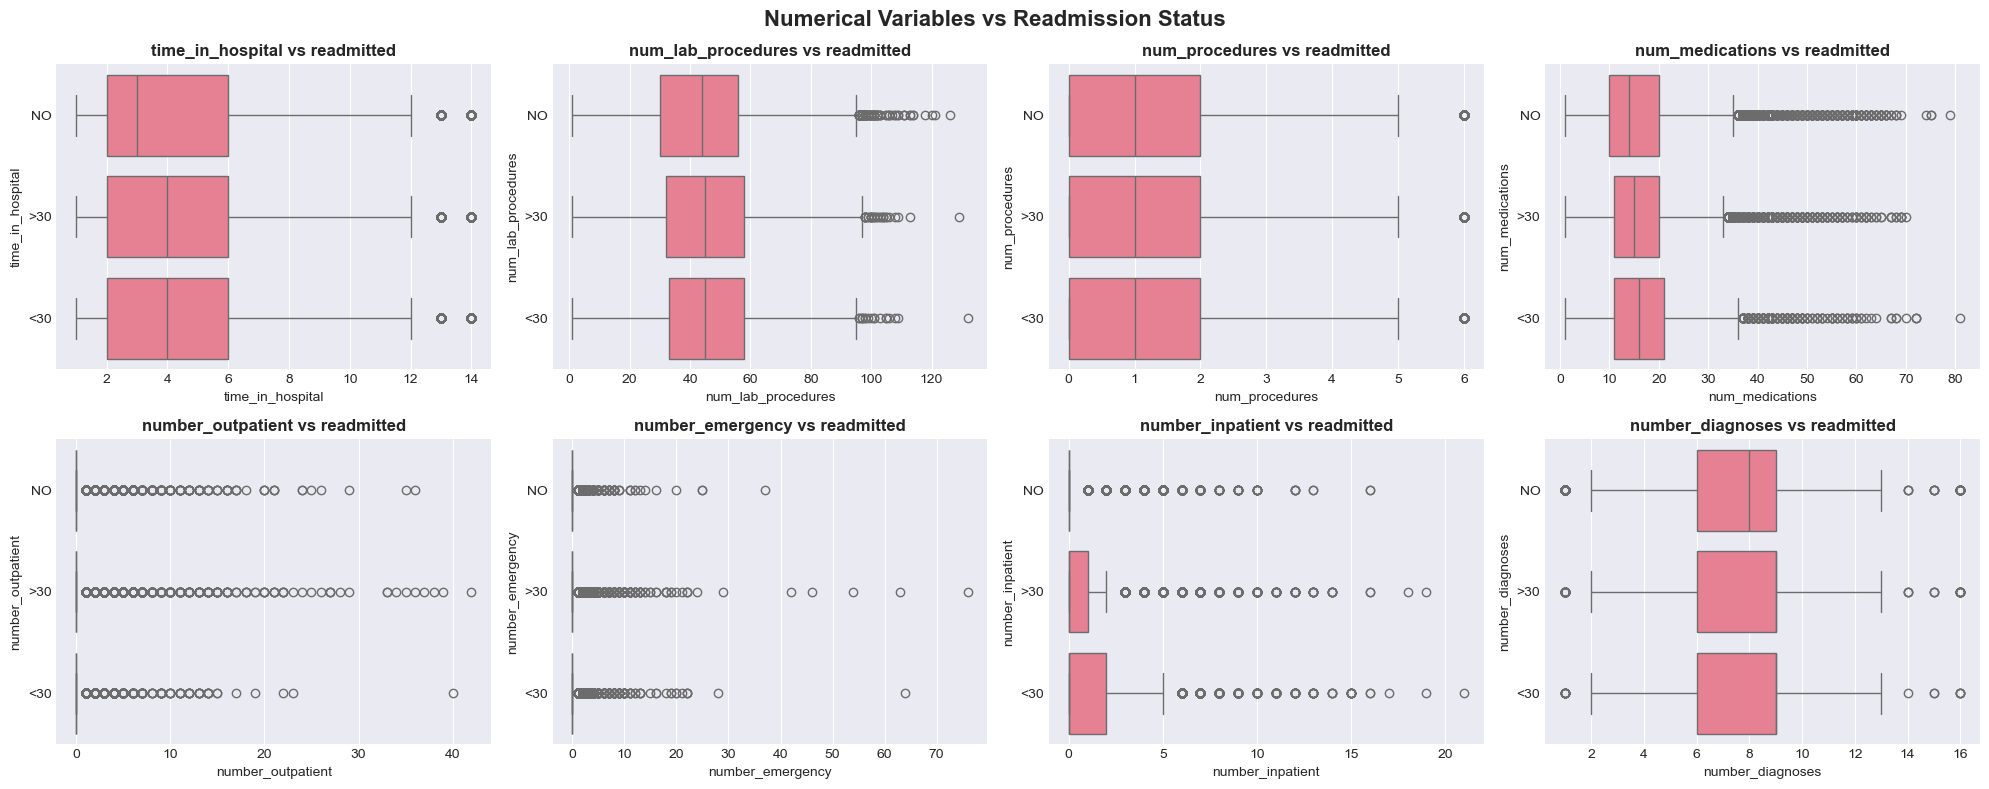

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 4
n_rows = (len(numerical_var) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

target = 'readmitted' 

for i, col in enumerate(numerical_var):
    sns.boxplot(x=col, y=target, data=df, ax=axes[i], order=["NO", ">30", "<30"])
    axes[i].set_title(f'{col} vs {target}', fontweight='bold')
    axes[i].set_ylabel(col)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Numerical Variables vs Readmission Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# can tell that time_in_hospital quite relevant to different between readmitted vs no readmitted
# quite significant relationship for number_inpatient against target variable

#### Kruskal-Wallis statistical test (KIV, i not sure about the math behind this one)


 Numerical Variables Association with Target (Kruskal-Wallis):
             Variable  H_Statistic        P_Value  Epsilon_Squared  \
0    number_inpatient  5662.510562   0.000000e+00         0.055624   
1    number_emergency  1651.950219   0.000000e+00         0.016214   
2   number_outpatient  1252.145232  1.259267e-272         0.012285   
3    number_diagnoses  1209.976706  1.806744e-263         0.011870   
4     num_medications   547.538532  1.269166e-119         0.005361   
5    time_in_hospital   469.236271  1.278317e-102         0.004591   
6      num_procedures   235.093213   8.915741e-52         0.002291   
7  num_lab_procedures   173.416574   2.203279e-38         0.001684   

  Effect_Size Significant  
0       Small         Yes  
1       Small         Yes  
2       Small         Yes  
3       Small         Yes  
4       Small         Yes  
5       Small         Yes  
6       Small         Yes  
7       Small         Yes  


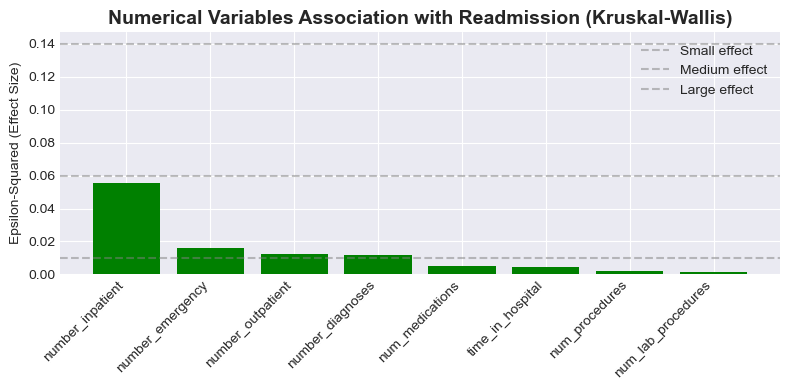

In [25]:
from scipy.stats import kruskal
import pandas as pd
import matplotlib.pyplot as plt

numerical_associations = []

for col in numerical_var:
    # Get groups based on readmission status
    groups = [df[df['readmitted'] == cat][col].dropna() for cat in df['readmitted'].unique()]
    
    # Perform Kruskal-Wallis test
    H_stat, p_value = kruskal(*groups)
    
    # Effect size: Epsilon-squared (ε²)
    N = sum([len(g) for g in groups])  # total sample size
    k = len(groups)                    # number of groups
    epsilon_sq = (H_stat - (k - 1)) / (N - k) if (N - k) > 0 else 0
    
    numerical_associations.append({
        'Variable': col,
        'H_Statistic': H_stat,
        'P_Value': p_value,
        'Epsilon_Squared': epsilon_sq,
        'Effect_Size': 'Large' if epsilon_sq > 0.14 else 'Medium' if epsilon_sq > 0.06 else 'Small',
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

num_assoc_df = pd.DataFrame(numerical_associations).sort_values('Epsilon_Squared', ascending=False).reset_index(drop=True)
print("\n Numerical Variables Association with Target (Kruskal-Wallis):")
print(num_assoc_df)

plt.figure(figsize=(8, 4))
colors = ['green' if x == 'Yes' else 'red' for x in num_assoc_df['Significant']]
plt.bar(range(len(num_assoc_df)), num_assoc_df['Epsilon_Squared'], color=colors)
plt.xticks(range(len(num_assoc_df)), num_assoc_df['Variable'], rotation=45, ha='right')
plt.ylabel("Epsilon-Squared (Effect Size)")
plt.title("Numerical Variables Association with Readmission (Kruskal-Wallis)", fontsize=14, fontweight='bold')
plt.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Small effect')
plt.axhline(y=0.06, color='gray', linestyle='--', alpha=0.5, label='Medium effect')
plt.axhline(y=0.14, color='gray', linestyle='--', alpha=0.5, label='Large effect')
plt.legend()
plt.tight_layout()
plt.show()

### Categorical Variable Analysis

#### Bar plot distribution

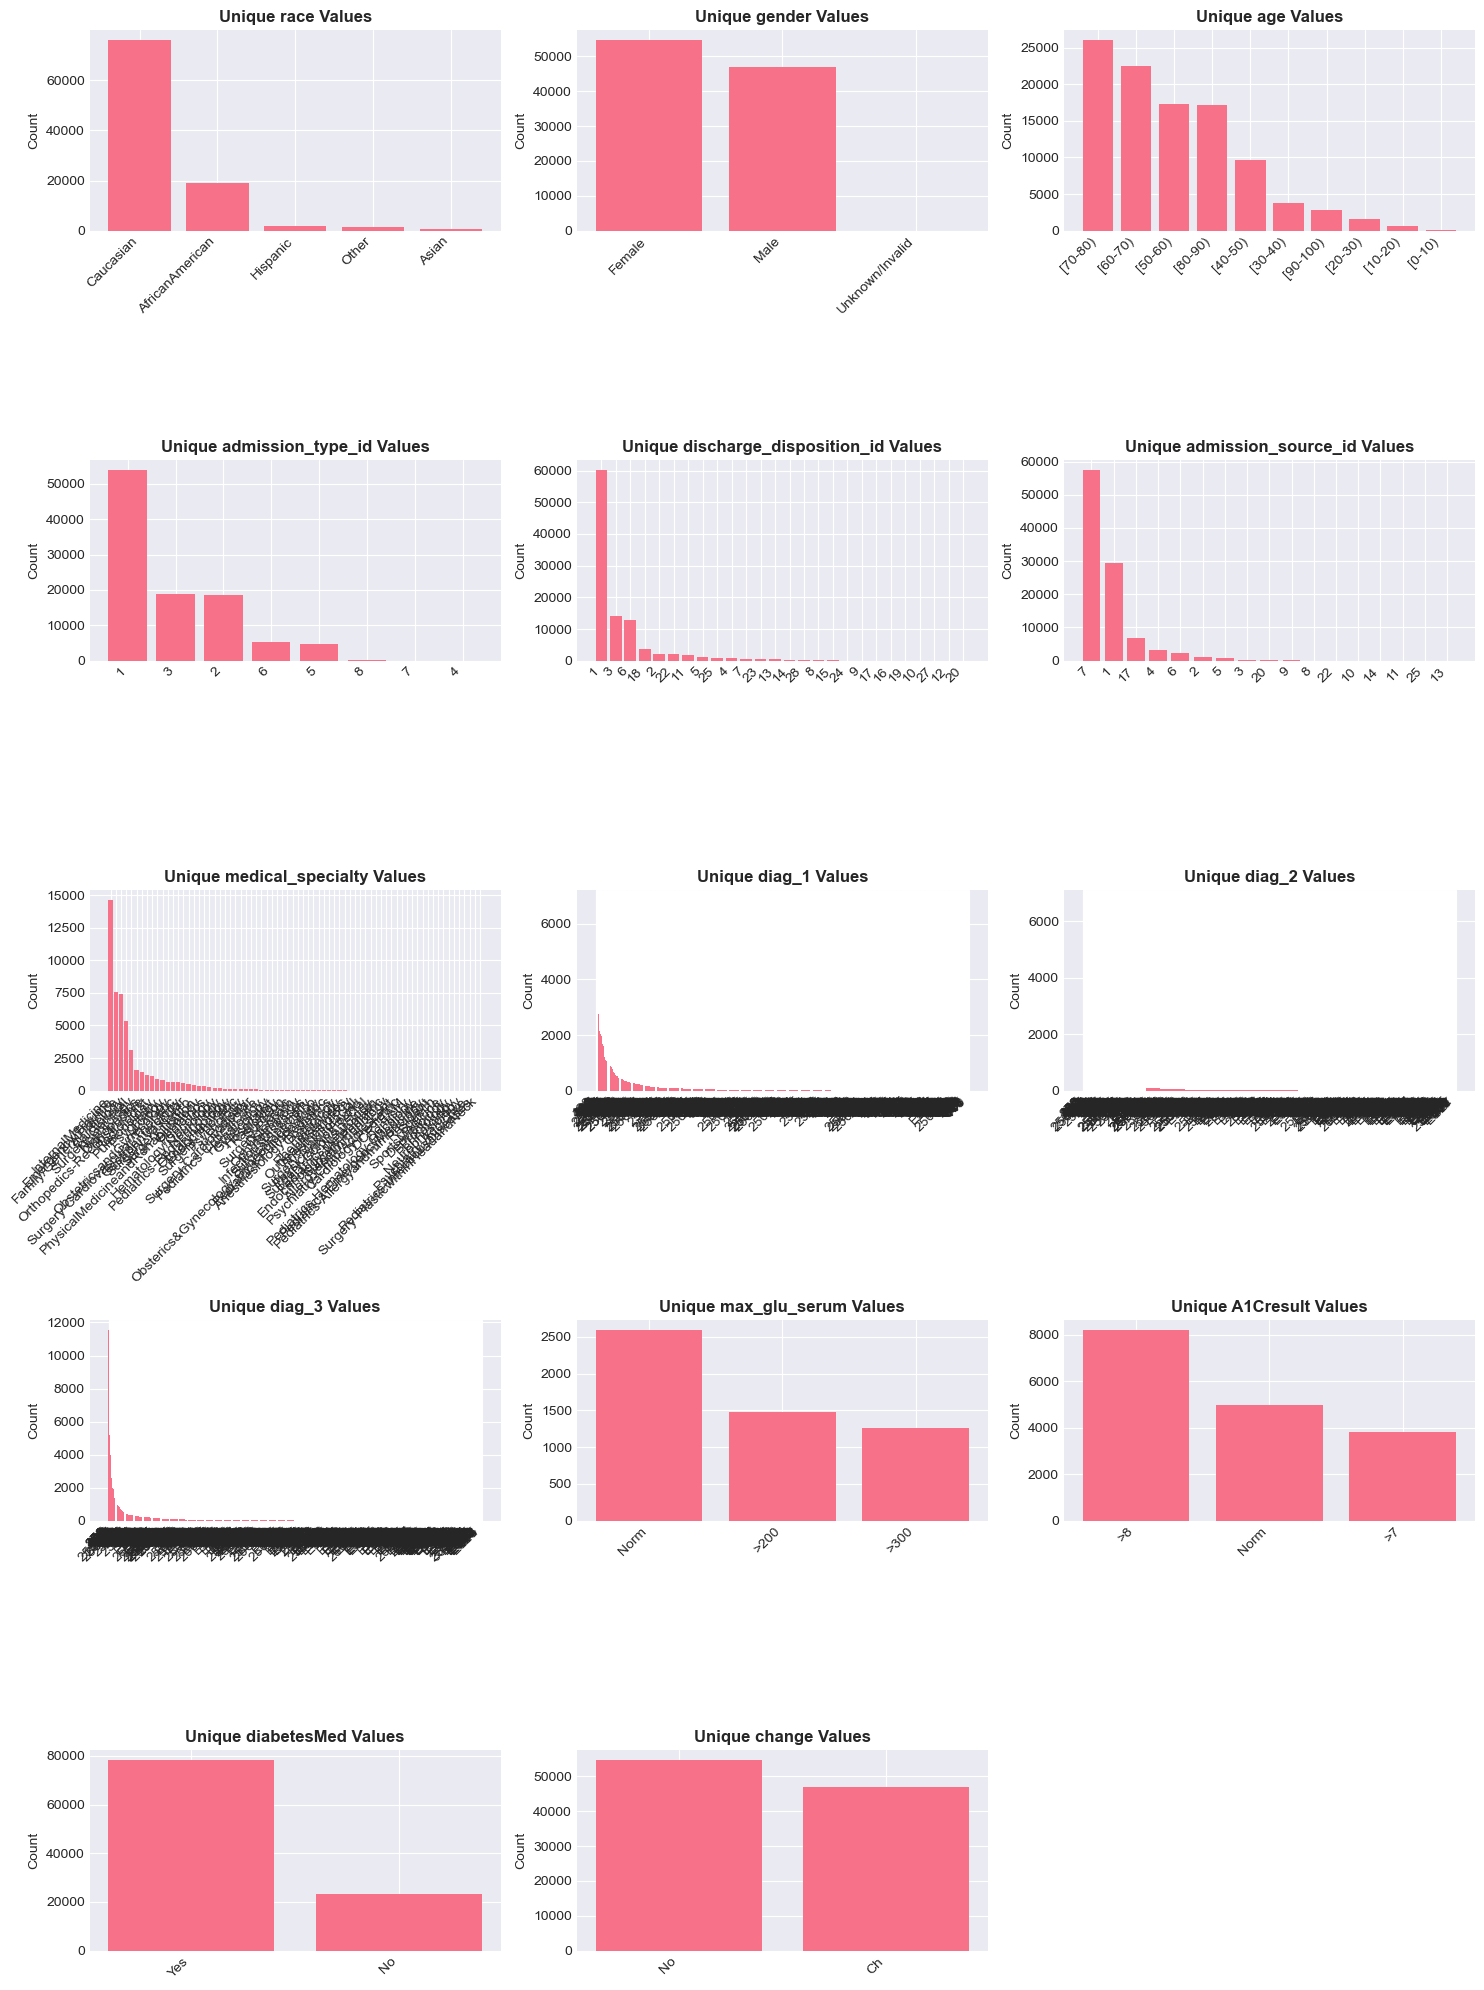

In [27]:
# Analyze key categorical variables
key_categorical = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 
                  'admission_source_id', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 
                   'max_glu_serum', 'A1Cresult', 'diabetesMed', 'change']

n_cols = 3
n_rows = (len(key_categorical) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(key_categorical[:]):
    if col in df.columns:
        value_counts = df[col].value_counts()
        axes[i].bar(range(len(value_counts)), value_counts.values)
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[i].set_title(f'Unique {col} Values', fontweight='bold')
        axes[i].set_ylabel('Count')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

#### PATTERNS WITH TARGET VARIABLE (READMISSION)

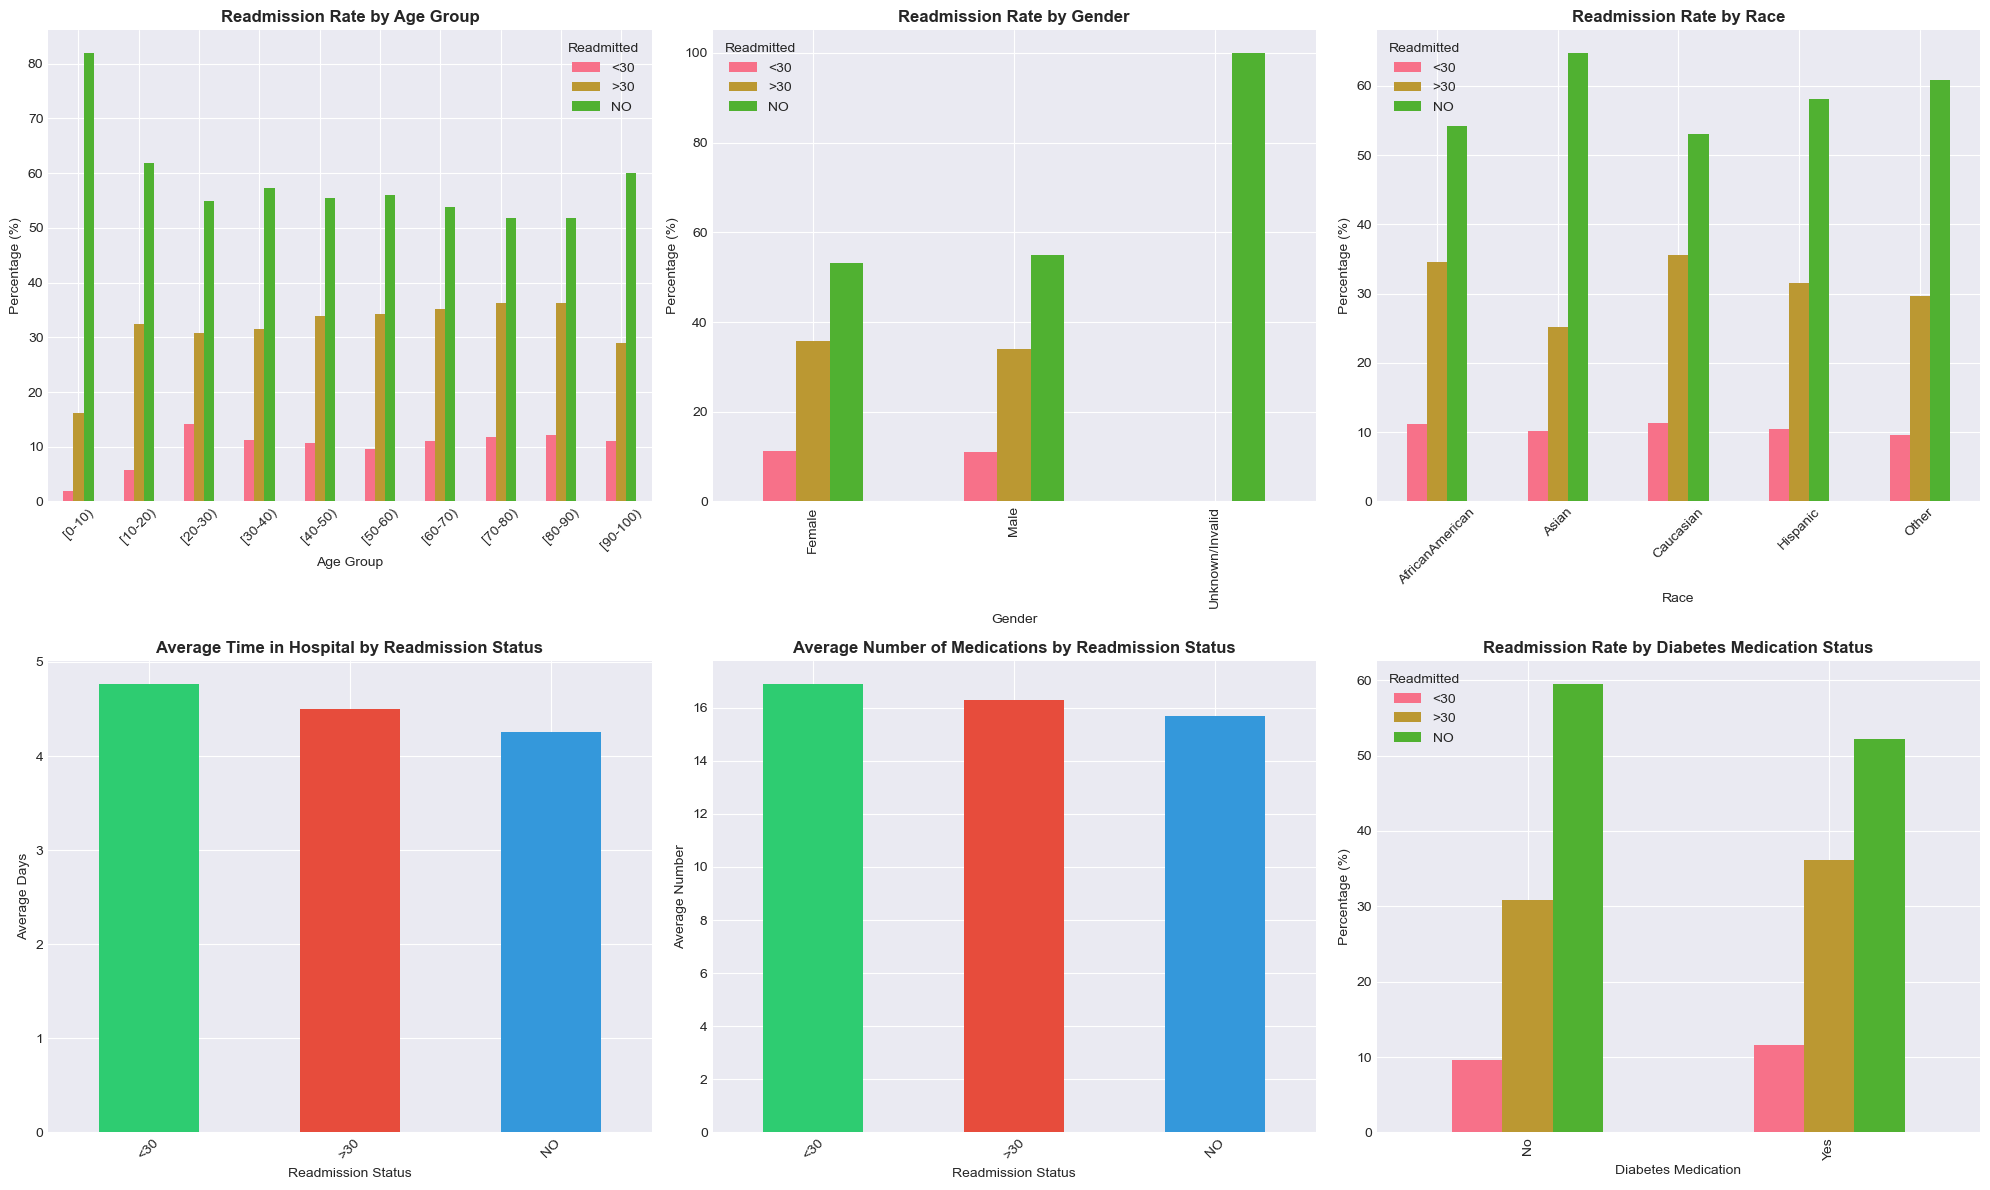

In [28]:
print("\n" + "="*80)
print("")
print("="*80)

# Readmission rate by demographic factors
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Age vs Readmission
readmit_age = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
readmit_age.plot(kind='bar', stacked=False, ax=axes[0, 0])
axes[0, 0].set_title('Readmission Rate by Age Group', fontweight='bold')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(title='Readmitted')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gender vs Readmission
readmit_gender = pd.crosstab(df['gender'], df['readmitted'], normalize='index') * 100
readmit_gender.plot(kind='bar', stacked=False, ax=axes[0, 1])
axes[0, 1].set_title('Readmission Rate by Gender', fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(title='Readmitted')

# Race vs Readmission
readmit_race = pd.crosstab(df['race'], df['readmitted'], normalize='index') * 100
readmit_race.plot(kind='bar', stacked=False, ax=axes[0, 2])
axes[0, 2].set_title('Readmission Rate by Race', fontweight='bold')
axes[0, 2].set_xlabel('Race')
axes[0, 2].set_ylabel('Percentage (%)')
axes[0, 2].legend(title='Readmitted')
axes[0, 2].tick_params(axis='x', rotation=45)

# Time in hospital vs Readmission
readmit_time = df.groupby('readmitted')['time_in_hospital'].mean()
readmit_time.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1, 0].set_title('Average Time in Hospital by Readmission Status', fontweight='bold')
axes[1, 0].set_xlabel('Readmission Status')
axes[1, 0].set_ylabel('Average Days')
axes[1, 0].tick_params(axis='x', rotation=45)

# Number of medications vs Readmission
readmit_meds = df.groupby('readmitted')['num_medications'].mean()
readmit_meds.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1, 1].set_title('Average Number of Medications by Readmission Status', fontweight='bold')
axes[1, 1].set_xlabel('Readmission Status')
axes[1, 1].set_ylabel('Average Number')
axes[1, 1].tick_params(axis='x', rotation=45)

# Diabetes medication vs Readmission
readmit_diabmed = pd.crosstab(df['diabetesMed'], df['readmitted'], normalize='index') * 100
readmit_diabmed.plot(kind='bar', stacked=False, ax=axes[1, 2])
axes[1, 2].set_title('Readmission Rate by Diabetes Medication Status', fontweight='bold')
axes[1, 2].set_xlabel('Diabetes Medication')
axes[1, 2].set_ylabel('Percentage (%)')
axes[1, 2].legend(title='Readmitted')

plt.tight_layout()
plt.show()

#### Kendall's Tau statistical test